# Attention Map Tests

> $by \ @SleepyLGod$

This notebook is a simple test of the attention map containing the attention scores of each token in the input & output sequence. 

- Basically, the attention map is a matrix of size $(num_{heads}, num_{tokens}, num_{tokens})$ where each element $(i, j, k)$ represents the attention score of the i-th head of the k-th token to the j-th token.
- Attention scores are calculated by the dot product of the query and key vectors of the attention mechanism, i.e. $score = Q \cdot K^T/\sqrt{d}$.

### Model import

We use the `transformers` library to import the model: `meta-llama/Llama-3.2-1B`

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, utils
utils.logging.set_verbosity_error()  # Suppress standard warnings
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.2-1B')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-1B')
model.eval() # Disable dropout (optional)
# tokenizer = AutoTokenizer.from_pretrained("gpt2")
# model = AutoModelForCausalLM.from_pretrained("gpt2", output_attentions=True)
tag = 0

### Data

Either **one partiicular prompt** or **a dataset of prompts**

- `input_ids`: The input sequence of tokens.
- `attention_mask`: The attention mask for the input sequence.
- `token_type_ids`: The token type ids for the input sequence.

In [9]:
import torch

tag = 0
prompt = "I am xiaoming and he's name is Patrick, and one day," #"Once upon a time, a monkey named Sun Wukong was born"
input_ids = tokenizer.encode(prompt, return_tensors="pt")
attention_mask = torch.ones_like(input_ids)
input_len = input_ids.shape[1]

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
from datasets import load_dataset

tag = 1

# Set padding token
tokenizer.pad_token = tokenizer.eos_token

# Step 1: Load and Tokenize the Dataset
def tokenize_dataset(dataset, tokenizer, max_length=512):
    tokenized_dataset = dataset.map(
        lambda examples: tokenizer(examples['instruction'], 
                                    truncation=True, 
                                    padding='max_length', 
                                    max_length=max_length),
        batched=True
    )
    return tokenized_dataset

# Load Alpaca dataset
ds = load_dataset("tatsu-lab/alpaca")
small_dataset = ds['train'].select(range(50))  # Adjust the range as needed
tokenized_dataset = tokenize_dataset(small_dataset, tokenizer)

### Basic Observations of the Attention Map

- watch the change of the map given some particular head numbers and output size.

In [ ]:
import matplotlib.pyplot as plt
# Set generation parameters
max_length = 5  # Number of tokens to generate
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

# Function to sample the next token (using argmax for simplicity)
def sample_token(logits):
    return torch.argmax(logits[:, -1, :], dim=-1)

# Lists to store generated tokens and attentions
generated_tokens = []
all_attentions = []
seq_tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

# Generation loop
for step in range(max_length):
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    attentions = outputs.attentions  # Tuple of layers, each is (1, num_heads, seq_len, seq_len)
    logits = outputs.logits  # (1, seq_len, vocab_size)
    next_token = sample_token(logits)  # Sample the next token
    generated_tokens.append(next_token.item())
    seq_tokens.append(tokenizer.decode(next_token))
    
    # Collect full attention maps for the entire sequence up to this step
    step_attentions = []
    seq_len = input_ids.shape[1]
    for layer in range(num_layers):
        layer_attentions = []
        for head in range(num_heads):
            attn = attentions[layer][0, head, :, :seq_len].detach().numpy()
            layer_attentions.append(attn)
        step_attentions.append(layer_attentions)
    all_attentions.append(step_attentions)
    
    # Append the generated token to input_ids and attention_mask for the next step
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1,1)], dim=1)

# Visualization
for step, step_attentions in enumerate(all_attentions):
    generated_token = seq_tokens[input_len + step]
    print(f"Generated token {step+1}: {generated_token}")
    for layer in range(num_layers):
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
        axes = axes.flatten()
        selected_heads = [0, 1, 2, 3]
        for idx, head in enumerate(selected_heads):
            ax = axes[idx]
            ax.matshow(step_attentions[layer][head], cmap='viridis', vmin=0, vmax=1)
            ax.set_title(f'Head {head}', fontsize=12)
            ax.set_xlabel('Input/Generated Tokens', fontsize=10)
            tokens_up_to_step = seq_tokens[:input_len + step + 1]
            ax.set_xticks(range(len(tokens_up_to_step)))
            ax.set_xticklabels(tokens_up_to_step, rotation=90, fontsize=8)
            ax.set_yticks(range(len(tokens_up_to_step)))
            ax.set_yticklabels(tokens_up_to_step, fontsize=8)
        # Add color bar
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(axes[0].images[0], cax=cax)
        plt.suptitle(f'Attention Maps for Token {generated_token} at Step {step+1}, Layer {layer}', fontsize=14)
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        # Save the plot to a file
        plt.savefig(f'../images/maps_0/attention_map_step_{step+1}_layer_{layer}.png')
        plt.close()

In [ ]:
# then just pick 2 heads to visualize in only one picture (maybe really long)
# and also add the text of the generated tokens on the side
# print the pictures below, no need to save
# Visualization
selected_heads = [0, 1]
for step, step_attentions in enumerate(all_attentions):
    generated_token = seq_tokens[input_len + step]
    print(f"Generated token {step+1}: {generated_token}")
    for layer in range(num_layers):
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
        for idx, head in enumerate(selected_heads):
            ax = axes[idx]
            ax.matshow(step_attentions[layer][head], cmap='viridis', vmin=0, vmax=1)
            ax.set_title(f'Head {head}', fontsize=12)
            ax.set_xlabel('Input/Generated Tokens', fontsize=10)
            tokens_up_to_step = seq_tokens[:input_len + step + 1]
            ax.set_xticks(range(len(tokens_up_to_step)))
            ax.set_xticklabels(tokens_up_to_step, rotation=90, fontsize=8)
            ax.set_yticks(range(len(tokens_up_to_step)))
            ax.set_yticklabels(tokens_up_to_step, fontsize=8)
        # Add color bar
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(axes[0].images[0], cax=cax)
        plt.suptitle(f'Attention Maps for Token {generated_token} at Step {step+1}, Layer {layer}', fontsize=14)
        plt.tight_layout(rect=[0, 0, 0.9, 1])
        # Display the plot
        # plt.savefig(f'./images/maps_0_simplifized/attention_map_step_{step+1}_layer_{layer}.png')
        plt.show()
        plt.close()

### Layer attention map observation

- Main points: given the head_number and one particular prompt, and for each layer, we can observe the change of attention map as the token is generating.
- Also, we can observe the change of attention map as we go deeper with the layer number.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
max_seq_len = 70
specified_head = 8  # Intermediate head index
eos_token_id = tokenizer.eos_token_id

print("input_ids: ", input_ids)
print("attention_mask: ", attention_mask)
print("input_ids shape: ", input_ids.shape)
print("initial eos_token_id: ", eos_token_id)

# Initialize lists to collect attention scores for each layer
attention_scores_per_layer = {i: [] for i in range(len(model.model.layers))}

# Token generation loop
while len(input_ids[0]) < max_seq_len:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
        # print(outputs.logits.shape)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        break
    # Collect attention scores for the last token in the sequence for each layer and specified head
    for layer_idx, attentions in enumerate(outputs.attentions):
        # attentions shape: (1, num_heads, seq_len, seq_len)
        # Get attention scores for the specified head and last token
        seq_len = len(input_ids[0])
        # print("seq_len: ", seq_len)
        attention_scores = attentions[0, specified_head, -1, :seq_len].detach().cpu().numpy()
        attention_scores_per_layer[layer_idx].append(attention_scores)
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    if len(input_ids[0]) >= max_seq_len:
        break

# Find the maximum attention score for normalization
max_attention_score = 0
for layer_scores in attention_scores_per_layer.values():
    for step_scores in layer_scores:
        current_max = np.max(step_scores)
        if current_max > max_attention_score:
            max_attention_score = current_max

# Plotting attention scores as heatmaps with white borders and normalized colors
num_layers = len(model.model.layers)
for layer_idx in range(num_layers):
    # Get the attention scores for this layer
    scores = attention_scores_per_layer[layer_idx]
    # Determine the maximum sequence length
    max_seq_length = len(scores[-1])
    # Prepare data with separators
    heatmap_data_list = []
    for step, score in enumerate(scores):
        # Pad the score to the maximum sequence length
        padded_score = np.pad(score, (0, max_seq_length - len(score)), mode='constant')
        # Normalize the score
        normalized_score = padded_score / max_attention_score
        heatmap_data_list.append(normalized_score)
        # Add a column of zeros as a separator, except after the last step
        if step != len(scores) - 1:
            separator = np.zeros_like(padded_score)
            heatmap_data_list.append(separator)
    # Convert to a matrix for heatmap and transpose for correct orientation
    heatmap_data = np.column_stack(heatmap_data_list)
    plt.figure(figsize=(20, 12))  # Adjusted figure size
    plt.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=0, vmax=1) # viridis
    plt.xlabel('Generation Step with Separators')
    plt.ylabel('Sequence Position')
    plt.title(f'Layer {layer_idx}, Head {specified_head}')
    plt.colorbar(label='Attention Score (0-1)')
    plt.xticks(ticks=np.arange(0, heatmap_data.shape[1], 2), labels=np.arange(1, heatmap_data.shape[1]//2 + 2))
    plt.savefig(f'../images/maps_layer/heatmap_layer_{layer_idx}_head_{specified_head}.png')
    plt.close()


input_ids:  tensor([[128000,     40,   1097,    865,    689,  18238,    323,    568,    596,
            836,    374,  20199,     11,    323,    832,   1938,     11]])
attention_mask:  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
input_ids shape:  torch.Size([1, 17])
initial eos_token_id:  128001


### Head attention map observation

- Main points: given the layer number and one particular prompt, and for each head, we can observe the change of attention map as the token is generating.
- Also, we can observe the change of attention map as we go deeper with the head number.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
selected_layer = len(model.model.layers) - 2  # Second last layer
num_heads = model.config.num_attention_heads
max_seq_len = 70
eos_token_id = tokenizer.eos_token_id

# Initialize lists to collect attention scores for each head
attention_scores_per_head = {i: [] for i in range(num_heads)}

# Token generation loop
while len(input_ids[0]) < max_seq_len:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        break
    for layer_idx, attentions in enumerate(outputs.attentions):
        if layer_idx == selected_layer:
            seq_len = len(input_ids[0])
            for head_idx in range(num_heads):
                attention_scores = attentions[0, head_idx, -1, :seq_len].detach().cpu().numpy()
                attention_scores_per_head[head_idx].append(attention_scores)
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    if len(input_ids[0]) >= max_seq_len:
        break

# Find the maximum attention score for normalization
max_attention_scores = {head_idx: 0 for head_idx in range(num_heads)}
for head_idx, scores in attention_scores_per_head.items():
    for step_scores in scores:
        current_max = np.max(step_scores)
        if current_max > max_attention_scores[head_idx]:
            max_attention_scores[head_idx] = current_max

# Plotting attention scores as heatmaps with white borders and normalized colors
for head_idx in range(num_heads):
    scores = attention_scores_per_head[head_idx]
    max_seq_length = len(scores[-1])
    heatmap_data_list = []
    for step, score in enumerate(scores):
        padded_score = np.pad(score, (0, max_seq_length - len(score)), mode='constant')
        normalized_score = padded_score / max_attention_scores[head_idx]
        heatmap_data_list.append(normalized_score)
        if step != len(scores) - 1:
            separator = np.zeros_like(padded_score)
            heatmap_data_list.append(separator)
    heatmap_data = np.column_stack(heatmap_data_list)
    plt.figure(figsize=(20, 12))
    plt.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
    plt.xlabel('Generation Step with Separators')
    plt.ylabel('Sequence Position')
    plt.title(f'Layer {selected_layer}, Head {head_idx}')
    plt.colorbar(label='Attention Score (0-1)')
    plt.xticks(ticks=np.arange(0, heatmap_data.shape[1], 2), labels=np.arange(1, heatmap_data.shape[1]//2 + 2))
    plt.savefig(f'../images/maps_head/heatmap_layer_{selected_layer}_head_{head_idx}.png')
    plt.close()

### Token-Layer attention map observation

- Main points: given the head number and one particular prompt, and for each token, we can observe the change of attention map as we go deeper with the layer number.

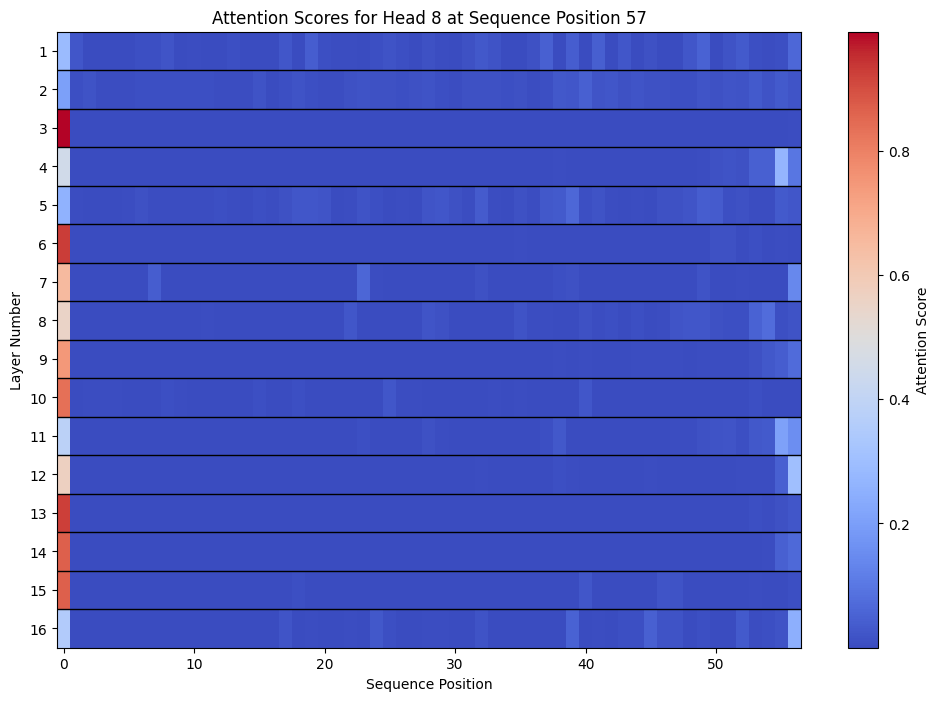

In [ ]:
# Parameters
max_seq_len = 70
specified_head = 8  # Head number 8
target_seq_length = input_len + 40  # Sequence length 15 after the initial prompt
eos_token_id = tokenizer.eos_token_id

# Initialize lists to collect attention scores for each layer at sequence length 10
attention_scores_at_seq10 = {i: None for i in range(len(model.model.layers))}

# Token generation loop
while len(input_ids[0]) < max_seq_len:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        break
    # Check if sequence length is now 10
    if len(input_ids[0]) == target_seq_length:
        for layer_idx, attentions in enumerate(outputs.attentions):
            # attentions shape: (1, num_heads, seq_len, seq_len)
            # Get attention scores for the specified head and 10th token
            attention_scores = attentions[0, specified_head, -1, :].detach().cpu().numpy()
            attention_scores_at_seq10[layer_idx] = attention_scores
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    if len(input_ids[0]) >= max_seq_len:
        break

# Now, attention_scores_at_seq10 contains the attention scores for each layer
# Plotting as a heatmap
import numpy as np
import matplotlib.pyplot as plt

num_layers = len(model.model.layers)
# Get the list of layers that have the attention scores collected
collected_layers = [layer_idx for layer_idx in attention_scores_at_seq10 if attention_scores_at_seq10[layer_idx] is not None]
# Get the corresponding attention scores
scores = [attention_scores_at_seq10[layer_idx] for layer_idx in collected_layers]

# Ensure all score vectors have the same length
if all(len(score) == target_seq_length for score in scores):
    scores_matrix = np.array(scores)
else:
    # Handle varying lengths if necessary
    max_len = max(len(score) for score in scores)
    scores_matrix = np.array([np.pad(score, (0, max_len - len(score)), mode='constant') for score in scores])

# Plotting
plt.figure(figsize=(12, 8))
plt.imshow(scores_matrix, aspect='auto', cmap='coolwarm')
plt.xlabel('Sequence Position')
plt.ylabel('Layer Number')
plt.yticks(ticks=np.arange(len(collected_layers)), labels=np.arange(1, len(collected_layers) + 1))
plt.title(f'Attention Scores for Head {specified_head} at Sequence Position {target_seq_length}')
plt.colorbar(label='Attention Score')

# Add white lines to separate rows
for i in range(1, len(collected_layers)):
    plt.axhline(i - 0.5, color='black', linewidth=1)

plt.savefig(f'../images/maps_token_l/attention_scores_head_{specified_head}_seq_{target_seq_length}_heatmap.png')
plt.show()

### Token-Head attention map observation

- Main points: given the layer number and one particular prompt, and for each token, we can observe the change of attention map as the head number changes.

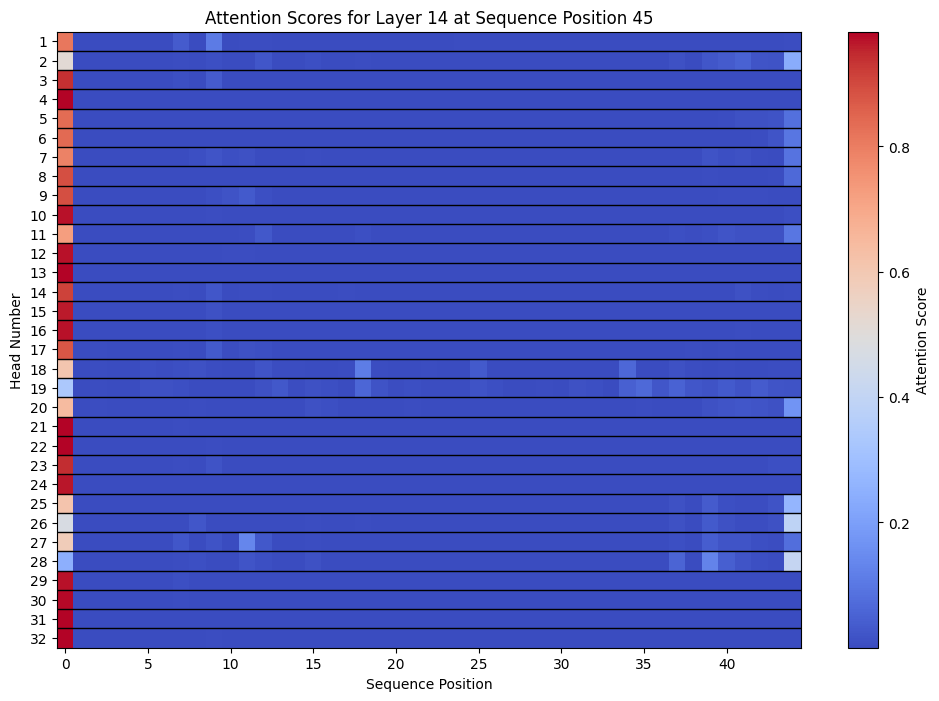

In [ ]:
# Parameters
target_seq_length = input_len + 30  # Sequence position for the 10th generated token
specified_layer = len(model.model.layers) - 2  # Second last layer
eos_token_id = tokenizer.eos_token_id
num_heads = model.config.num_attention_heads

# Initialize list to collect attention scores for all heads in the specified layer at target_seq_length
attention_scores_at_target = []

# Token generation loop
while len(input_ids[0]) < max_seq_len:
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, output_attentions=True)
    logits = outputs.logits[:, -1, :]
    next_token = torch.argmax(logits, dim=-1)
    if next_token.item() == eos_token_id:
        break
    # Check if sequence length is now target_seq_length
    if len(input_ids[0]) == target_seq_length:
        attentions = outputs.attentions[specified_layer]
        # attentions shape: (1, num_heads, seq_len, seq_len)
        # Collect attention scores for all heads at the last token (position target_seq_length)
        for head_idx in range(num_heads):
            attention_scores = attentions[0, head_idx, -1, :].detach().cpu().numpy()
            attention_scores_at_target.append(attention_scores)
    # Append the next token to input_ids and attention_mask
    input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    attention_mask = torch.cat([attention_mask, torch.ones(1, 1)], dim=1)
    if len(input_ids[0]) >= max_seq_len:
        break

# Now, attention_scores_at_target contains the attention scores for all heads in the specified layer
# Plotting as a heatmap
import numpy as np
import matplotlib.pyplot as plt

num_heads = len(attention_scores_at_target)
# Ensure all score vectors have the same length
if all(len(score) == target_seq_length for score in attention_scores_at_target):
    scores_matrix = np.array(attention_scores_at_target)
else:
    # Handle varying lengths if necessary
    max_len = max(len(score) for score in attention_scores_at_target)
    scores_matrix = np.array([np.pad(score, (0, max_len - len(score)), mode='constant') for score in attention_scores_at_target])

# Plotting
plt.figure(figsize=(12, 8))
plt.imshow(scores_matrix, aspect='auto', cmap='coolwarm')
plt.xlabel('Sequence Position')
plt.ylabel('Head Number')
plt.yticks(ticks=np.arange(num_heads), labels=np.arange(1, num_heads + 1))
plt.title(f'Attention Scores for Layer {specified_layer} at Sequence Position {target_seq_length}')
plt.colorbar(label='Attention Score')

# Add white lines to separate rows
for i in range(1, num_heads):
    plt.axhline(i - 0.5, color='black', linewidth=1)

plt.savefig(f'../images/maps_token_h/attention_scores_layer_{specified_layer}_seq_{target_seq_length}_heatmap.png')
plt.show()

### Dataset attention map observation

- Dataset: alpaca
- Metrics:
- Design:
- Observations:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'

def get_attention_scores(model, tokenized_dataset, device='cpu'):
    model.eval()
    model.to(device)
    attention_scores = []
    batch_size = 4  # Adjust based on CPU memory
    for i in range(0, len(tokenized_dataset), batch_size):
        batch = tokenized_dataset[i:i+batch_size]
        input_ids = torch.tensor(batch['input_ids']).to(device)
        attention_mask = torch.tensor(batch['attention_mask']).to(device)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
            batch_attentions = outputs.attentions  # List of layers, each is (batch, heads, seq, seq)
            attention_scores.append(batch_attentions)
    return attention_scores

attention_scores = get_attention_scores(model, tokenized_dataset, device)

# Step 4: Calculate Metrics
def calculate_metrics(attention_scores):
    # Flatten the list of attention scores
    flattened_scores = [score for batch in attention_scores for layer in batch for score in layer]
    
    # Find the maximum sequence length
    max_seq_len = max(score.shape[-1] for score in flattened_scores)
    
    # Pad all attention scores to have the same sequence length
    padded_scores = []
    for score in flattened_scores:
        padded_score = np.pad(score, ((0, 0), (0, 0), (0, 0), (0, max_seq_len - score.shape[-1])), mode='constant')
        padded_scores.append(padded_score)
    
    # Convert list of padded scores to numpy array
    attention_scores_np = np.array(padded_scores)
    
    # Calculate average attention score per head across all layers and positions
    avg_per_head = np.mean(attention_scores_np, axis=(0, 2, 3))
    
    # Calculate variance of attention scores per layer across all heads and positions
    var_per_layer = np.var(attention_scores_np, axis=(1, 3, 4))
    
    # Calculate entropy of attention distributions per head and layer
    entropy_per_head_layer = -np.sum(attention_scores_np * np.log(attention_scores_np + 1e-10), axis=-1)
    
    # Calculate correlation between attention scores of different heads within the same layer
    correlation_matrix = np.zeros((model.config.num_layers, model.config.num_attention_heads, model.config.num_attention_heads))
    for layer in range(model.config.num_layers):
        for head1 in range(model.config.num_attention_heads):
            for head2 in range(model.config.num_attention_heads):
                corr = np.corrcoef(attention_scores_np[:, layer, head1].flatten(), attention_scores_np[:, layer, head2].flatten())[0,1]
                correlation_matrix[layer, head1, head2] = corr
    
    return {
        'avg_per_head': avg_per_head,
        'var_per_layer': var_per_layer,
        'entropy_per_head_layer': entropy_per_head_layer,
        'correlation_matrix': correlation_matrix
    }

metrics = calculate_metrics(attention_scores)

# Step 5: Visualize Metrics
def plot_metrics(metrics):
    # Average attention score per head
    plt.figure(figsize=(10, 6))
    plt.plot(metrics['avg_per_head'])
    plt.title('Average Attention Score per Head')
    plt.xlabel('Head Number')
    plt.ylabel('Average Attention Score')
    plt.savefig('avg_attention_per_head.png')
    plt.show()
    
    # Variance of attention scores per layer
    plt.figure(figsize=(10, 6))
    plt.plot(metrics['var_per_layer'])
    plt.title('Variance of Attention Scores per Layer')
    plt.xlabel('Layer Number')
    plt.ylabel('Variance')
    plt.savefig('variance_per_layer.png')
    plt.show()
    
    # Entropy of attention distributions per head and layer
    plt.figure(figsize=(12, 8))
    for layer in range(model.config.num_layers):
        plt.subplot(4, 8, layer+1)
        plt.imshow(metrics['entropy_per_head_layer'][layer])
        plt.title(f'Entropy - Layer {layer}')
        plt.colorbar()
    plt.tight_layout()
    plt.savefig('entropy_per_head_layer.png')
    plt.show()
    
    # Correlation between attention scores of different heads within the same layer
    plt.figure(figsize=(12, 8))
    for layer in range(model.config.num_layers):
        plt.subplot(4, 8, layer+1)
        plt.imshow(metrics['correlation_matrix'][layer])
        plt.title(f'Correlation - Layer {layer}')
        plt.colorbar()
    plt.tight_layout()
    plt.savefig('correlation_per_head.png')
    plt.show()

plot_metrics(metrics)

### Rubbish bin

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate output with attention for tag 0, i.e., only one input
# output = model(input_ids, output_attentions=True)
# attentions = output.attentions

# # Extract attention maps for the first num_tokens generated tokens
# num_tokens = 4
# attention_maps = [attn[0, :, :num_tokens, :num_tokens].detach().numpy() for attn in attentions]

# # Print some metrics
# print(f"Number of layers: {len(attention_maps)}")
# print(f"Number of heads: {attention_maps[0].shape[0]}")
# print(f"Number of tokens: {num_tokens}")
# print(f"Dimensions of the attention maps: {attention_maps[0].shape}")

# # Print the input tokens
# tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
# print("Input tokens:", tokens)

# # Print the output tokens
# output_tokens = output.logits[0, -num_tokens:, :].argmax(dim=-1)
# output_tokens = tokenizer.convert_ids_to_tokens(output_tokens)
# print("Output tokens:", output_tokens)

# # Plot attention maps with distinct colors and borders
# fig, axes = plt.subplots(len(attention_maps), num_tokens, figsize=(15, 70))
# for i, layer_attention in enumerate(attention_maps):
#     for j in range(num_tokens):
#         ax = axes[i, j]
#         # Display attention for each head
#         for head in range(layer_attention.shape[0]):
#             cax = ax.matshow(layer_attention[head, j].reshape(1, -1), cmap='viridis')
#             ax.set_title(f'Head {head+1}', fontsize=10)
#             ax.set_xticks([])
#             ax.set_yticks([])
#             for spine in ax.spines.values():
#                 spine.set_edgecolor('black')
#                 spine.set_linewidth(1)
#         if j == 0:
#             ax.set_ylabel(f'Layer {i+1}', fontsize=15, rotation=0, labelpad=50)
# # Add colorbar horizontally at the bottom
# cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.02])
# fig.colorbar(cax, cax=cbar_ax, orientation='horizontal')
# plt.tight_layout()
# plt.show()

# # Print metrics of the attention maps
# for i, layer_attention in enumerate(attention_maps):
#     print(f"Layer {i+1}")
#     for j in range(num_tokens):
#         print(f"Token {j+1}")
#         for head in range(layer_attention.shape[0]):
#             print(f"  Head {head+1}")
#             print("    Min:", np.min(layer_attention[head, j]))
#             print("    Max:", np.max(layer_attention[head, j]))
#             print("    Mean:", np.mean(layer_attention[head, j]))
#             print("    Std:", np.std(layer_attention[head, j]))
#             print()